# Mental Health Semantics — SVC baseline + DistilBERT advanced model

**What this notebook does**:

- Loads your dataset from `Combined Data.csv` (uses `statement` as text and `status` as labels).
- Cleans data, trains a **TF-IDF + LinearSVC** baseline and a **DistilBERT** classifier (fine-tune optional).
- Caches embeddings and models so long runs can resume.
- Provides a `predict_condition` function that returns class probabilities in the format you asked:

```
depression - 40%
anxiety - 30%
sad - 10%
Overall - Depression
```

**Notes**: DistilBERT fine-tuning benefits from a GPU; the notebook includes an optional, configurable training cell.

In [1]:
%%bash
python -V
pip install -q --upgrade pip
pip install -q sentence-transformers transformers datasets evaluate accelerate scikit-learn joblib matplotlib seaborn nbformat


  s l :   U n k n o w n   k e y   ' a u t o m o u n t . c r o s s D i s t r o '   i n   / e t c / w s l . c o n f : 3 
 <3>WSL (10 - Relay) ERROR: CreateProcessCommon:725: execvpe(/bin/bash) failed: No such file or directory


CalledProcessError: Command 'b'python -V\npip install -q --upgrade pip\npip install -q sentence-transformers transformers datasets evaluate accelerate scikit-learn joblib matplotlib seaborn nbformat\n'' returned non-zero exit status 1.

In [3]:
!pip install datasets transformers evaluate scikit-learn



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sentence_transformers import SentenceTransformer

# Constants
DATA_PATH = 'Combined Data.csv'
RANDOM_STATE = 42
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)


In [5]:
df = pd.read_csv(DATA_PATH)
# Drop unnamed index if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
# Ensure columns exist
print('Columns:', df.columns.tolist())
# Use 'statement' and 'status' as discovered earlier
if 'statement' not in df.columns or 'status' not in df.columns:
    raise ValueError('Expected columns "statement" and "status" in CSV')

# Clean text column
df['statement'] = df['statement'].astype(str).fillna('')
df['status'] = df['status'].astype(str).fillna('')

# Simple class balance check
print('Dataset size:', len(df))
print(df['status'].value_counts())

# Train/validation split
X = df['statement']
y = df['status']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Train size:', len(X_train), 'Val size:', len(X_val))

Columns: ['statement', 'status']
Dataset size: 53043
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64
Train size: 42434 Val size: 10609


In [7]:
# Baseline: TF-IDF + LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
import joblib, os

tfidf = TfidfVectorizer()
svc_pipe = Pipeline([
    ('tfidf', tfidf),
    ('clf', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE))
])

param_grid_svc = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__max_features': [20000, 40000],
    'clf__C': [0.5, 1.0]
}

print('Running GridSearchCV for LinearSVC...')
grid_svc = GridSearchCV(
    estimator=svc_pipe,
    param_grid=param_grid_svc,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=1,   # ✅ avoid pickling/memory issues
    verbose=2
)

grid_svc.fit(X_train, y_train)

best_svc = grid_svc.best_estimator_
print('Best SVC params:', grid_svc.best_params_)

# Save best SVC
svc_path = os.path.join(MODEL_DIR, 'best_svc.joblib')
joblib.dump(best_svc, svc_path)
print('Saved SVC to', svc_path)


Running GridSearchCV for LinearSVC...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


[CV] END clf__C=0.5, tfidf__max_features=20000, tfidf__ngram_range=(1, 1); total time=   3.2s


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


[CV] END clf__C=0.5, tfidf__max_features=20000, tfidf__ngram_range=(1, 1); total time=   2.9s


...

[CV] END clf__C=1.0, tfidf__max_features=40000, tfidf__ngram_range=(1, 2); total time=   9.3s


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


[CV] END clf__C=1.0, tfidf__max_features=40000, tfidf__ngram_range=(1, 2); total time=   9.0s


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Best SVC params: {'clf__C': 0.5, 'tfidf__max_features': 40000, 'tfidf__ngram_range': (1, 2)}
Saved SVC to models\best_svc.joblib


=== Best TF-IDF + Linear SVC ===

Classification Report:
                      precision    recall  f1-score   support

             Anxiety     0.8028    0.8059    0.8044       778
             Bipolar     0.8025    0.7704    0.7862       575
          Depression     0.7732    0.6861    0.7271      3081
              Normal     0.8932    0.9489    0.9202      3270
Personality disorder     0.6667    0.7583    0.7096       240
              Stress     0.5898    0.6086    0.5991       534
            Suicidal     0.6872    0.7236    0.7049      2131

            accuracy                         0.7857     10609
           macro avg     0.7451    0.7574    0.7502     10609
        weighted avg     0.7850    0.7857    0.7842     10609

Accuracy: 0.7857479498538976


<Figure size 600x600 with 0 Axes>

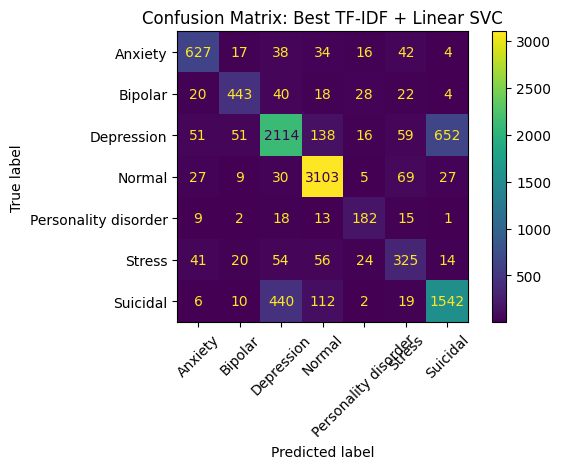

In [8]:
def evaluate_model(model, X_te, y_te, title='Model'):
    print(f'=== {title} ===')
    y_pred = model.predict(X_te)
    print('\nClassification Report:')
    print(classification_report(y_te, y_pred, digits=4))
    print('Accuracy:', accuracy_score(y_te, y_pred))
    cm = confusion_matrix(y_te, y_pred, labels=np.unique(y_te))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_te))
    plt.figure(figsize=(6,6))
    disp.plot(values_format='d', xticks_rotation=45)
    plt.title(f'Confusion Matrix: {title}')
    plt.tight_layout()
    plt.show()

# Evaluate saved SVC
best_svc = joblib.load(svc_path)
evaluate_model(best_svc, X_val, y_val, title='Best TF-IDF + Linear SVC')

Loaded cached embeddings


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Trained and saved SVC on embeddings
=== SVC on SentenceTransformer embeddings ===

Classification Report:
                      precision    recall  f1-score   support

             Anxiety     0.7648    0.7481    0.7563       778
             Bipolar     0.7186    0.7374    0.7279       575
          Depression     0.7366    0.6488    0.6899      3081
              Normal     0.8904    0.9315    0.9105      3270
Personality disorder     0.3872    0.5792    0.4641       240
              Stress     0.4735    0.6030    0.5305       534
            Suicidal     0.6521    0.6377    0.6448      2131

            accuracy                         0.7419     10609
           macro avg     0.6605    0.6980    0.6749     10609
        weighted avg     0.7470    0.7419    0.7426     10609

Accuracy: 0.741917240079178


<Figure size 600x600 with 0 Axes>

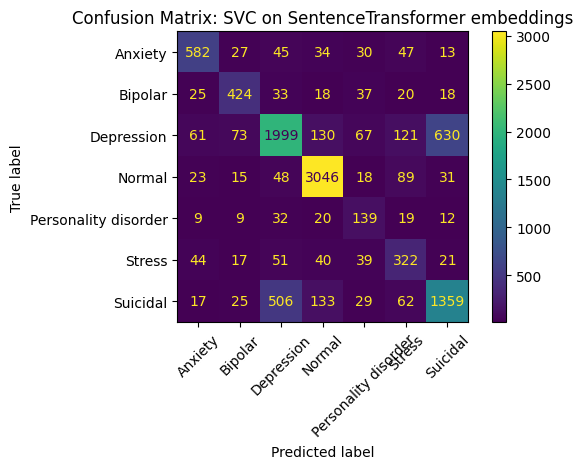

In [9]:
# Semantic embeddings (SentenceTransformer) + SVC on embeddings
emb_model_name = 'all-MiniLM-L6-v2'  # fast and effective
emb_model = SentenceTransformer(emb_model_name)

emb_cache_train = os.path.join(MODEL_DIR, 'X_train_emb.npy')
emb_cache_val = os.path.join(MODEL_DIR, 'X_val_emb.npy')

if os.path.exists(emb_cache_train):
    X_train_emb = np.load(emb_cache_train)
    X_val_emb = np.load(emb_cache_val)
    print('Loaded cached embeddings')
else:
    print('Encoding embeddings (this may take a while)...')
    X_train_emb = emb_model.encode(list(X_train), batch_size=64, show_progress_bar=True, convert_to_numpy=True)
    X_val_emb = emb_model.encode(list(X_val), batch_size=64, show_progress_bar=True, convert_to_numpy=True)
    np.save(emb_cache_train, X_train_emb)
    np.save(emb_cache_val, X_val_emb)
    print('Saved embeddings')

# Train LinearSVC on embeddings
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

svc_emb_pipe = make_pipeline(StandardScaler(), LinearSVC(class_weight='balanced', random_state=RANDOM_STATE))
svc_emb_pipe.fit(X_train_emb, y_train)
joblib.dump(svc_emb_pipe, os.path.join(MODEL_DIR, 'svc_embeddings.joblib'))
print('Trained and saved SVC on embeddings')

evaluate_model(svc_emb_pipe, X_val_emb, y_val, title='SVC on SentenceTransformer embeddings')

In [10]:
# DistilBERT fine-tuning (optional, recommended to run on GPU)
# If you have limited resources, set DO_TRAIN=False below to skip fine-tuning.
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

DO_TRAIN = False  # change to True if you want to fine-tune DistilBERT
MODEL_NAME = 'distilbert-base-uncased'
NUM_LABELS = len(y.unique())

if DO_TRAIN:
    print('Preparing datasets for Hugging Face Trainer...')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    def tokenize_fn(batch):
        return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=128)

    # Map labels to integers
    label_list = list(y.unique())
    label_to_id = {l:i for i,l in enumerate(label_list)}

    hf_train = Dataset.from_dict({'text': list(X_train), 'label': [label_to_id[x] for x in y_train]})
    hf_val   = Dataset.from_dict({'text': list(X_val), 'label': [label_to_id[x] for x in y_val]})

    hf_train = hf_train.map(lambda batch: tokenize_fn(batch), batched=True)
    hf_val = hf_val.map(lambda batch: tokenize_fn(batch), batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)

    training_args = TrainingArguments(
        output_dir='./distilbert_ckpt',
        evaluation_strategy='epoch',
        save_strategy='epoch',
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.01,
        push_to_hub=False,
        logging_steps=50,
        load_best_model_at_end=True
    )

    metric = evaluate.load('f1')

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        # compute macro F1 using evaluate
        from sklearn.metrics import f1_score
        return {'f1_macro': f1_score(labels, preds, average='macro')}

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=hf_train,
        eval_dataset=hf_val,
        compute_metrics=compute_metrics
    )

    trainer.train()
    trainer.save_model('./models/distilbert_finetuned')
    print('Saved DistilBERT model to ./models/distilbert_finetuned')
else:
    print('Skipping DistilBERT fine-tuning. Set DO_TRAIN=True to enable it (GPU recommended).')

Skipping DistilBERT fine-tuning. Set DO_TRAIN=True to enable it (GPU recommended).


In [15]:
# Prediction helper with percentage output and 'Overall' logic
from collections import OrderedDict

# helper to get probability-like scores for models that don't offer predict_proba
def get_probs_from_model(model, texts, label_order=None):
    # texts: list of strings
    try:
        probs = model.predict_proba(texts)
        classes = model.classes_
        return probs, classes
    except Exception:
        # no predict_proba (e.g., LinearSVC). We'll use decision_function and convert to softmax
        if hasattr(model, 'decision_function'):
            dec = model.decision_function(texts)
            # handle binary case where shape is (n,) or (n,1)
            if dec.ndim == 1:
                dec = np.vstack([-dec, dec]).T
            # softmax
            exp = np.exp(dec - np.max(dec, axis=1, keepdims=True))
            probs = exp / exp.sum(axis=1, keepdims=True)
            classes = model.classes_
            return probs, classes
        else:
            # As a fallback, use predict and a one-hot-like distribution
            preds = model.predict(texts)
            classes = model.classes_
            probs = np.zeros((len(texts), len(classes)))
            for i, p in enumerate(preds):
                probs[i, list(classes).index(p)] = 1.0
            return probs, classes

def format_prediction_output(texts, probs, classes):
    # returns a list of formatted strings per input
    out = []
    for i, text in enumerate(texts):
        row = probs[i]
        # create mapping class->percentage
        mapping = {c: float(row[j])*100 for j, c in enumerate(classes)}
        # sort by probability desc
        sorted_items = sorted(mapping.items(), key=lambda x: x[1], reverse=True)
        # format top classes (all classes)
        lines = []
        for cls, val in sorted_items:
            lines.append(f"{cls} - {val:.1f}%")
        overall = sorted_items[0][0]
        lines.append(f"Overall - {overall}")
        out.append('\n'.join(lines))
    return out

def predict_condition_formatted(texts, model=None, model_path=None):
    if isinstance(texts, str):
        texts = [texts]
    if model is None:
        if model_path is None:
            model_path = svc_path
        model = joblib.load(model_path)
    probs, classes = get_probs_from_model(model, texts)
    formatted = format_prediction_output(texts, probs, classes)
    return list(zip(texts, formatted))

# Example usage with the SVC baseline
samples = [
    # "I've been feeling overwhelmed and anxious lately, can't sleep at night.",
    # "Life has been really good and I'm excited about the future!",
    # "I feel empty and can't focus on anything.",
    "Lately I’ve been laughing more at gatherings and everyone thinks I’m doing fine, but when I get home I feel this emptiness that keeps me awake at night, and no amount of distraction seems to quiet it"
    # "I’ve been trying to stay positive at work and smile around my friends, but deep inside I feel this constant weight pressing on my chest, making me anxious and drained, and sometimes I wonder if I’ll ever truly feel normal again."
]

print(predict_condition_formatted(samples, model=best_svc))

[('Lately I’ve been laughing more at gatherings and everyone thinks I’m doing fine, but when I get home I feel this emptiness that keeps me awake at night, and no amount of distraction seems to quiet it', 'Depression - 21.4%\nStress - 19.2%\nNormal - 16.7%\nAnxiety - 14.8%\nBipolar - 12.7%\nSuicidal - 7.9%\nPersonality disorder - 7.3%\nOverall - Depression')]


In [12]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, accuracy_score

# 1. Wrap your best SVC model with probability calibration
svc_with_probs = CalibratedClassifierCV(best_svc, cv=3)
svc_with_probs.fit(X_train, y_train)

# 2. Define evaluation function
def evaluate_prob_model(model, X_test, y_test):
    """
    Evaluate a probability-outputting model on test data.
    Prints accuracy and classification report.
    """
    label_list = model.classes_
    preds = []
    
    for text in X_test:
        # get probabilities
        probs = model.predict_proba([text])[0]
        # pick the label with max probability
        overall = label_list[probs.argmax()]
        preds.append(overall)

    print("Accuracy:", accuracy_score(y_test, preds))
    print("\nClassification Report:\n", classification_report(y_test, preds))

# 3. Run evaluation on validation/test set
evaluate_prob_model(svc_with_probs, X_val, y_val)


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Accuracy: 0.7881986992176454

Classification Report:
                       precision    recall  f1-score   support

             Anxiety       0.85      0.77      0.81       778
             Bipolar       0.88      0.73      0.80       575
          Depression       0.72      0.75      0.74      3081
              Normal       0.89      0.96      0.92      3270
Personality disorder       0.73      0.61      0.67       240
              Stress       0.71      0.50      0.59       534
            Suicidal       0.70      0.69      0.70      2131

            accuracy                           0.79     10609
           macro avg       0.78      0.72      0.74     10609
        weighted avg       0.79      0.79      0.79     10609



In [16]:
# -----------------------
# Save the final best model (Balanced)
# -----------------------
import joblib
import os

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Save the best pipeline (TF-IDF + LinearSVC)
model_path = os.path.join(MODEL_DIR, "mental_health_balanced_model.joblib")
joblib.dump(best_svc, model_path)

print(f"✅ Model saved at: {model_path}")


✅ Model saved at: models\mental_health_balanced_model.joblib
